In [1]:
import argparse
import logging
import re
import sys
import warnings
from pathlib import Path
import numpy as np
from statsmodels.stats.multitest import multipletests

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad

import rpy2.robjects as ro
import anndata2ri
import rpy2.rinterface_lib.callbacks as rcb
from rpy2.robjects.conversion import localconverter

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams["font.family"] = (
    "Arial" if "Arial" in [f.name for f in fm.fontManager.ttflist] else "sans-serif"
)
plt.rcParams["font.weight"] = "normal"

sys.path.insert(1, "/dss/dsshome1/0C/ra98gaq/Git/cellseg-benchmark")
from cellseg_benchmark.dea_utils import prepare_adata_for_rpy2, subset_by_brain_region


def get_args(test_args=None):
    p = argparse.ArgumentParser(description="Run MAST single-cell-based DEA")
    p.add_argument("cohort", help="Cohort name, e.g. foxf2")
    p.add_argument(
        "seg_method", help="Segmentation method, e.g. Cellpose_1_nuclei_model"
    )
    p.add_argument(
        "--sample_key", default="sample", help="obs column for donor/sample ID"
    )
    p.add_argument(
        "--subset_key",
        default="cell_type",
        help="obs column used to subset data (e.g. cell_type, cluster, region)",
    )
    p.add_argument(
        "--subset_values",
        nargs="+",
        default=None,
        help="Values of subset_key to process (default: all unique values)",
    )
    p.add_argument(
        "--condition_key",
        default="genotype",
        help="obs column for condition (e.g. genotype)",
    )
    p.add_argument(
        "--batch_key",
        default="slide",
        help="optional batch key for inclusion as covariate (default: slide)",
    )
    p.add_argument("--ref", default="WT", help="Reference group (default: WT)")
    p.add_argument(
        "--test_groups",
        nargs="+",
        default=None,
        help="Groups to test vs reference (default: all groups in condition_key except --ref)",
    )
    p.add_argument(
        "--brain_region_subset",
        default=None,
        help="Alias (cortex, hippocampus, white_matter, grey_matter) or comma-separated raw labels.",
    )
    p.add_argument("--overwrite", default=False, help="Overwrite cache?")

    if test_args is not None:
        return p.parse_args(test_args)
    else:
        return p.parse_args()

In [2]:
# Simulate CLI arguments inside Jupyter
args = get_args(
    [
        "aging",
        "vpt_3D_DAPI_nuclei",
        "--sample_key",
        "sample",
        "--subset_key",
        "cell_type",
        "--condition_key",
        "condition",
        "--batch_key",
        "slide",
        "--ref",
        "WT_3",
        # "--brain_region_subset", "grey_matter"
    ]
)

In [3]:
# Simulate CLI arguments inside Jupyter
args = get_args(
    [
        "foxf2",
        "Cellpose_1_nuclei_model",
        "--sample_key",
        "sample",
        "--subset_key",
        "cell_type",
        "--condition_key",
        "genotype",
        "--batch_key",
        "slide",
        "--ref",
        "WT",
        # "--brain_region_subset", "white_matter"
    ]
)

In [5]:
# Simulate CLI arguments inside Jupyter
args = get_args(
    [
        "aging",
        "Proseg_3D_Cellpose_1_nuclei_model",
        "--sample_key",
        "sample",
        "--subset_key",
        "cell_type",
        "--condition_key",
        "condition",
        "--batch_key",
        "slide",
        "--ref",
        "WT_3",
        # "--brain_region_subset", "grey_matter"
    ]
)

In [6]:
args

Namespace(cohort='aging', seg_method='Proseg_3D_Cellpose_1_nuclei_model', sample_key='sample', subset_key='cell_type', subset_values=None, condition_key='condition', batch_key='slide', ref='WT_3', test_groups=None, brain_region_subset=None, overwrite=False)

In [7]:
# Logger setup
logger = logging.getLogger("dea-MAST")
if not logger.handlers:
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter("%(asctime)s [%(levelname)s]: %(message)s"))
    logger.addHandler(handler)
    logger.setLevel(logging.INFO)
    logger.propagate = False
# rcb.logger.handlers = logger.handlers
# rcb.consolewrite_print = rcb.consolewrite_warnerror = lambda x: logger.info(f"R: {x.strip()}")

rcb.logger.handlers = logger.handlers
rcb.consolewrite_print = lambda x: logger.debug(f"R: {x.strip()}")
rcb.consolewrite_error = lambda x: (_ for _ in ()).throw(RRuntimeError(x.strip()))
rcb.consolewrite_message = lambda x: logger.info(f"R: {x.strip()}")
rcb.consolewrite_warn = lambda x: (
    logger.warning if x.lstrip().lower().startswith("warning") else logger.info
)(f"R: {x.strip()}")
setattr(rcb, "consolewrite_warnerror", rcb.consolewrite_warn)

In [8]:
base_path = Path("/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark")
method_path = base_path / "analysis" / args.cohort / args.seg_method
output_dir = method_path / "dea"
output_dir.mkdir(parents=True, exist_ok=True)

cache_dir = output_dir / "mast_dea_cache"
cache_dir.mkdir(parents=True, exist_ok=True)
logger.info(f"Using cache directory: {cache_dir}")

2026-01-20 16:39:54,163 [INFO]: Using cache directory: /dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/analysis/aging/Proseg_3D_Cellpose_1_nuclei_model/dea/mast_dea_cache


In [9]:
logger.info("Loading integrated AnnData...")
adata = sc.read_h5ad(method_path / "adatas" / "adata_integrated.h5ad.gz")
adata.obs["cell_type"] = adata.obs["cell_type_revised"]

2026-01-20 16:39:54,307 [INFO]: Loading integrated AnnData...


In [10]:
# re-group cell types
adata.obs["cell_type"] = (
    adata.obs["cell_type"]
    .astype(str)
    .replace(
        {
            "Tanycytes": "Ependymal",
            "Astroependymal": "Astrocytes",
            "Neurons-Glyc-Gaba": "Neurons-Other",
        }
    )
    .astype("category")
)

In [11]:
adata.obs["cell_type"].value_counts()

cell_type
Neurons-Glut                129550
Oligodendrocytes            121410
Neurons-Dopa                 80585
Astrocytes                   72012
ECs                          46563
Neurons-Granule-Immature     45584
Neurons-Other                43680
Undefined                    30909
Microglia                    27096
OPCs                         21142
Pericytes                    14331
VLMCs                         9762
SMCs                          7320
Ependymal                     6302
Choroid-Plexus                5873
Neurons-Gaba                  3423
BAMs                          1512
Immune-Other                   878
ABCs                            22
Name: count, dtype: int64

In [12]:
# Clean up group names for R conversion
adata.obs[args.subset_key] = [
    key.replace(" ", "_")
    .replace("-", "_")
    .replace("/", "_")
    .replace("+", "")
    .replace("(", "")
    .replace(")", "")
    if not pd.isna(key)
    else key
    for key in adata.obs[args.subset_key]
]
for col in [args.condition_key, args.sample_key, args.subset_key]:
    adata.obs[col] = adata.obs[col].astype("category")

In [13]:
if args.test_groups is None:
    groups = adata.obs[args.condition_key].dropna().unique().tolist()
    args.test_groups = [g for g in groups if g != args.ref]
    msg = (
        f"Test groups inferred from '{args.condition_key}': {', '.join(map(str, args.test_groups))}"
        if args.test_groups
        else f"No test groups found different from ref '{args.ref}' under '{args.condition_key}'."
    )
    logger.info(msg)
# sample overview
if args.subset_values is None:
    groups_to_process = sorted(adata.obs[args.subset_key].unique())
else:
    groups_to_process = args.subset_values
for cond, df in adata.obs.groupby(args.condition_key, observed=True):
    samples = df[args.sample_key].unique()
    logger.info(f"{cond}: {len(samples)} samples → {', '.join(samples)}")

2026-01-20 16:40:36,466 [INFO]: Test groups inferred from 'condition': WT_6, WT_12, WT_18, WT_24
2026-01-20 16:40:36,586 [INFO]: WT_3: 3 samples → aging_s8_r1, aging_s10_r1, aging_s10_r2
2026-01-20 16:40:36,588 [INFO]: WT_6: 3 samples → aging_s1_r0, aging_s5_r1, aging_s7_r2
2026-01-20 16:40:36,590 [INFO]: WT_12: 3 samples → aging_s5_r2, aging_s8_r0, aging_s12_r0
2026-01-20 16:40:36,591 [INFO]: WT_18: 3 samples → aging_s6_r0, aging_s8_r2, aging_s11_r0
2026-01-20 16:40:36,593 [INFO]: WT_24: 3 samples → aging_s10_r0, aging_s11_r1, aging_s11_r2


In [14]:
args.test_groups

['WT_6', 'WT_12', 'WT_18', 'WT_24']

In [15]:
adata.X = adata.layers["volume_log1p_norm"].copy()

In [16]:
# brain region subsetting (optional)
adata, chosen_brain_regions = subset_by_brain_region(
    adata, method_path, args.brain_region_subset, logger
)
if chosen_brain_regions:
    from cellseg_benchmark.adata_utils import plot_spatial_multiplot

    plot_spatial_multiplot(adata, "brain_region", size=0.2, figsize_per_ax=2)

In [17]:
adata = prepare_adata_for_rpy2(adata, key=args.subset_key)

In [18]:
del adata.varm
adata.obsm = {"spatial": adata.obsm["spatial"]}
del adata.obsp
adata.uns["pca"]["params"].pop("mask_var", None)

In [19]:
adata_dict = {}
unique_groups = adata.obs[args.subset_key].unique().tolist()
for key in unique_groups:
    tmp = adata[adata.obs[args.subset_key] == key].copy()
    adata_dict[key] = tmp
adata_dict["all"] = adata.copy()

In [20]:
adata_dict.keys()

dict_keys(['VLMCs', 'BAMs', 'SMCs', 'Neurons_Dopa', 'OPCs', 'Astrocytes', 'Microglia', 'ECs', 'Pericytes', 'Oligodendrocytes', 'Neurons_Gaba', 'Neurons_Glut', 'Undefined', 'Neurons_Other', 'Ependymal', 'Choroid_Plexus', 'Neurons_Granule_Immature', 'Immune_Other', 'ABCs', 'all'])

In [21]:
del adata

# Cluster genes

In [22]:
ad = adata_dict["all"]

In [23]:
ad.obs.age_months

aaaaaaaa-1       6
aaaaaaab-1       6
aaaaaaac-1       6
aaaaaaad-1       6
aaaaaaae-1       6
                ..
aaaalfma-1-9    12
aaaalfmb-1-9    12
aaaalfme-1-9    12
aaaalfmf-1-9    12
aaaalfmg-1-9    12
Name: age_months, Length: 667954, dtype: category
Categories (5, object): ['3', '6', '12', '18', '24']

In [24]:
ad

AnnData object with n_obs × n_vars = 667954 × 500
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'region', 'slide', 'cell_type_incl_low_quality_revised', 'cell_type_mmc_incl_low_quality_clusters', 'cell_type_mmc_incl_low_quality', 'cell_type_incl_mixed_revised', 'cell_type_mmc_incl_mixed_clusters', 'cell_type_mmc_incl_mixed', 'cell_type_revised', 'cell_type_mmc_raw_clusters', 'cell_type_mmc_raw', 'area', 'volume_sum', 'volume_trapz', 'volume_final', 'num_z_planes', 'size_normalized', 'surface_to_volume_ratio', 'sphericity', 'solidity', 'elongation', 'genotype', 'age_months', 'run_date', 'organism', 'cohort', 'sample', 'animal_id', 'condition', 'n_counts', 'n_genes', 'path', 'spatial_outlier', 'low_quality_cell', 'volume_outlier_cell', 'fov', 'cell_type'
    var: 'gene', 'total_count', 'lambda_bg_0', 'lambda_bg_1', 'lambda_bg_2', 'lambda_bg_3', 'lambda_bg_4', 'lambda_bg_5', 'lambda_bg_6', 'n_cells'
    uns: 

In [25]:
ad.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 71184739 stored elements and shape (667954, 500)>

In [26]:
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp

# --- 0) inputs ---
# ad: AnnData with ad.X = volume_log1p_norm (sparse CSR), ad.obs["age_months"] categorical strings
time_key = "age_months"

# Ensure timepoints are ordered numerically (3, 6, 12, 18, 24)
tp = ad.obs[time_key].astype(str)
tp_order = sorted(tp.unique(), key=lambda x: float(x))
ad.obs[time_key] = pd.Categorical(tp, categories=tp_order, ordered=True)

# --- 1) "unaggregated" usage: compute per-timepoint gene means directly from all cells ---
# This uses all cells, but reduces them to a gene x time summary (pseudobulk mean).
X = ad.X
if not sp.isspmatrix_csr(X):
    X = X.tocsr()

means = []
ns = []
for t in tp_order:
    idx = np.asarray(ad.obs[time_key] == t)
    ns.append(idx.sum())
    # mean over cells at this timepoint; stays efficient for sparse matrices
    m = X[idx].mean(axis=0)  # returns 1 x n_genes matrix
    means.append(np.asarray(m).ravel())  # to 1D

means = np.vstack(means)  # shape: (n_timepoints, n_genes)
ns = np.array(ns)

In [27]:
# --- 2) z-score each gene across timepoints (shape-based trajectories) ---
mu = means.mean(axis=0, keepdims=True)
sd = means.std(axis=0, ddof=0, keepdims=True)
sd[sd == 0] = 1.0
Z = (means - mu) / sd  # (n_timepoints, n_genes)

# Optional: keep these for inspection
# rows = timepoints, cols = genes
traj = pd.DataFrame(Z, index=tp_order, columns=ad.var_names)

given these clusters, how would you best compare them across cell types?

currently we are looking across all cell types ("all").

cell types are defined in the beginning

In [29]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster

# Z: (n_timepoints, n_genes) z-scored across time (from earlier)
# tp_order: list like ['3','6','12','18','24']
# ad.var_names: gene names

# 1) correlation-distance hierarchical clustering on gene trajectories
D = pdist(Z.T, metric="correlation")  # genes x timepoints -> distances between genes
L = linkage(D, method="average")  # average/complete both work; start with average

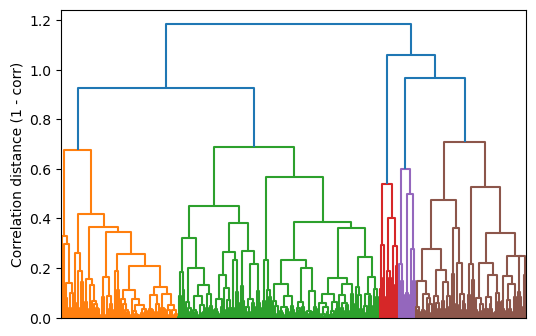

In [30]:
# find k


import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(6, 4))
dendrogram(L, no_labels=True)

# draw horizontal cut line
# find distance threshold for k clusters
from scipy.cluster.hierarchy import inconsistent
# simpler: visually choose a height or compute from fcluster output

# plt.axhline(y=x, color="red", linestyle="--")  # example value
plt.ylabel("Correlation distance (1 - corr)")
plt.show()

In [31]:
# define k
k = 6
labels = fcluster(L, t=k, criterion="maxclust").astype(str)
ad.var["time_cluster_hclust"] = labels

In [32]:
# plot

import matplotlib.pyplot as plt

df_long = (
    pd.DataFrame(Z.T, index=ad.var_names, columns=[float(x) for x in tp_order])
    .assign(cluster=labels)
    .reset_index(names="gene")
    .melt(id_vars=["gene", "cluster"], var_name="time", value_name="expression")
)

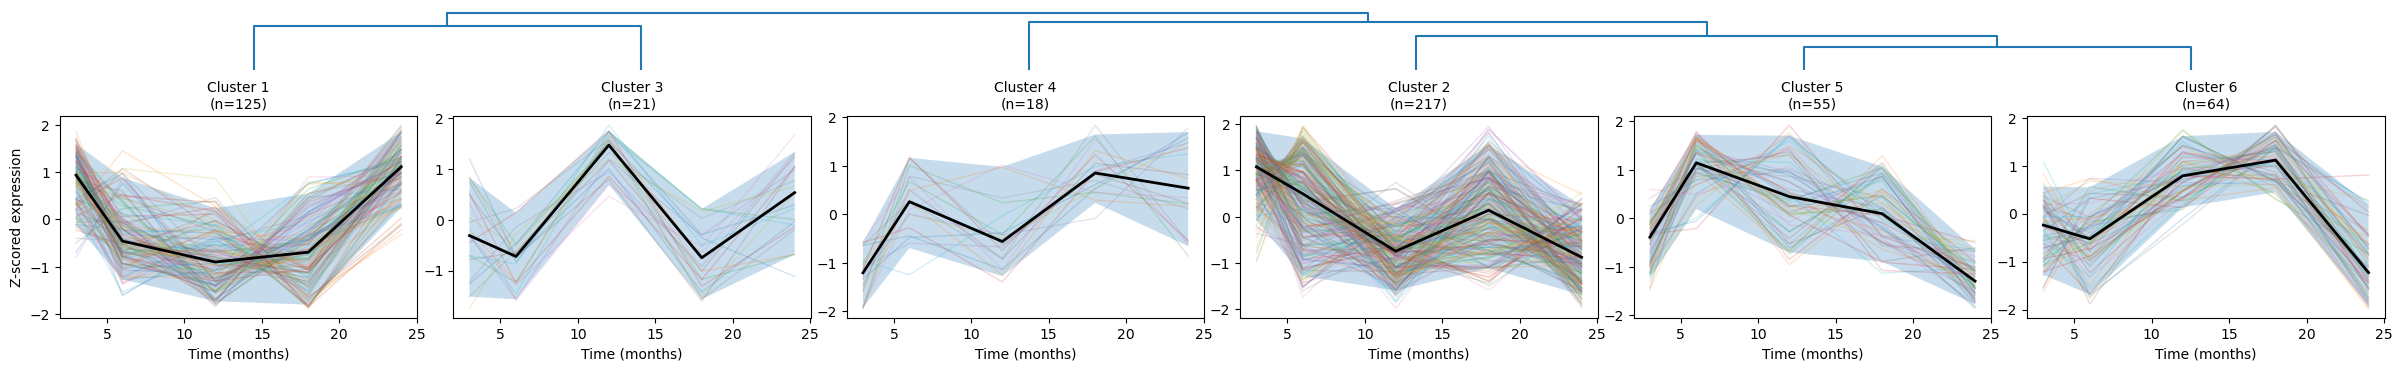

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# ---- cluster-level hierarchy (as before) ----
cluster_med = (
    df_long.groupby(["cluster", "time"])["expression"].median().unstack("time")
)

L_cl = linkage(pdist(cluster_med.to_numpy(), metric="correlation"), method="average")

clusters = cluster_med.index.astype(str).tolist()
n = len(clusters)

# ---- layout: dendrogram on top, clusters below ----
fig = plt.figure(figsize=(5 * n, 4))
gs = gridspec.GridSpec(
    nrows=2, ncols=n, height_ratios=[1.2, 4.0], hspace=0.35, wspace=0.1
)

# dendrogram axis (top, spanning all columns)
ax_d = fig.add_subplot(gs[0, :])
d = dendrogram(
    L_cl, labels=clusters, orientation="top", ax=ax_d, color_threshold=0, no_labels=True
)

# remove the box (spines) around the dendrogram axis
for spine in ax_d.spines.values():
    spine.set_visible(False)
ax_d.set_ylabel("")
ax_d.set_axis_off()

# leaf order left -> right
leaf_order = d["ivl"]

# ---- trajectory panels, ordered left -> right ----
for i, cl in enumerate(leaf_order):
    ax = fig.add_subplot(gs[1, i])
    sub = df_long[df_long["cluster"].astype(str) == str(cl)]
    n_genes = sub["gene"].nunique()

    # background genes
    for _, gsub in sub.groupby("gene", sort=False):
        gsub = gsub.sort_values("time")
        ax.plot(gsub["time"], gsub["expression"], alpha=0.2, linewidth=1)

    # median + band
    q = (
        sub.groupby("time")["expression"]
        .quantile([0.05, 0.5, 0.95])
        .unstack()
        .sort_index()
    )
    ax.fill_between(
        q.index.to_numpy(), q[0.05].to_numpy(), q[0.95].to_numpy(), alpha=0.25
    )
    ax.plot(q.index.to_numpy(), q[0.5].to_numpy(), color="black", linewidth=2)

    ax.set_title(f"Cluster {cl}\n(n={n_genes})", fontsize=10)
    ax.set_xlabel("Time (months)")
    if i == 0:
        ax.set_ylabel("Z-scored expression")
    else:
        ax.set_ylabel("")

plt.show()

In [34]:
genes_cluster_4 = ad.var_names[ad.var["time_cluster_hclust"] == "3"]
genes_cluster_4.tolist()

['AI593442',
 'Acta2',
 'Arpp21',
 'C1qtnf4',
 'Casz1',
 'Ddb2',
 'Dll3',
 'Drd1',
 'Fbn2',
 'H2-Aa',
 'Itga11',
 'Itga8',
 'Lamp5',
 'Ly6e',
 'Myh11',
 'Nos2',
 'Osr1',
 'Prdx1',
 'Pvalb',
 'Tnf',
 'Vcan']

# compare cell types

In [36]:
# gene -> program
ad.var["program"] = ad.var["time_cluster_hclust"]

In [38]:
import numpy as np
import pandas as pd
import scipy.sparse as sp

programs = ad.var["program"].dropna().astype(str).unique()
tp_order = sorted(ad.obs["age_months"].astype(str).unique(), key=float)

rows = []

for ct, ad_ct in adata_dict.items():
    if ct == "all":
        continue

    # ensure sparse CSR for fast row slicing/means
    Xct = ad_ct.X.tocsr() if sp.issparse(ad_ct.X) else ad_ct.X

    for t in tp_order:
        idx = np.asarray(ad_ct.obs["age_months"].astype(str) == t)  # <-- FIX
        if idx.sum() == 0:
            continue

        x_mean = np.asarray(Xct[idx].mean(axis=0)).ravel()

        for p in programs:
            genes = ad.var_names[ad.var["program"].astype(str) == p]
            gidx = ad_ct.var_names.get_indexer(genes)
            gidx = gidx[gidx >= 0]
            if gidx.size == 0:
                continue

            rows.append((ct, float(t), p, x_mean[gidx].mean()))

df_prog = pd.DataFrame(rows, columns=["cell_type", "time", "program", "score"])

# optional: within-program z-score for comparability
df_prog["zscore"] = df_prog.groupby("program")["score"].transform(
    lambda x: (x - x.mean()) / (x.std(ddof=0) if x.std(ddof=0) else 1.0)
)

In [40]:
# plot

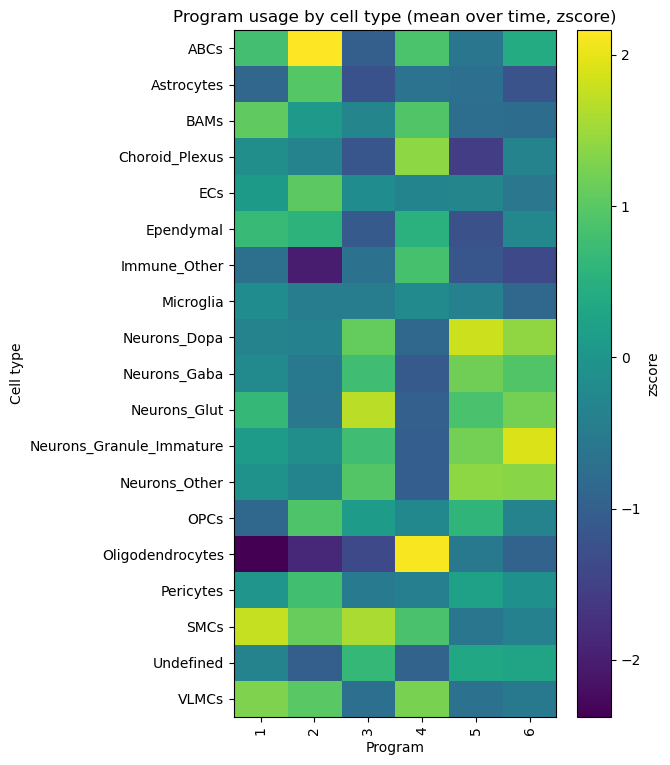

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# df_prog columns: cell_type, time (float), program, score, zscore
# choose which value to plot
val = "zscore"  # or "score"

# -------- A) Heatmap: programs x cell types (averaged over time) --------
cts = sorted(df_prog["cell_type"].unique())
progs = sorted(
    df_prog["program"].unique(), key=lambda x: int(x) if str(x).isdigit() else str(x)
)

M = (
    df_prog.groupby(["cell_type", "program"])[val]
    .mean()
    .unstack("program")
    .reindex(index=cts, columns=progs)
)

plt.figure(figsize=(0.6 * len(progs) + 3, 0.25 * len(cts) + 3))
plt.imshow(M.to_numpy(), aspect="auto")
plt.xticks(range(len(progs)), progs, rotation=90)
plt.yticks(range(len(cts)), cts)
plt.colorbar(label=val)
plt.xlabel("Program")
plt.ylabel("Cell type")
plt.title(f"Program usage by cell type (mean over time, {val})")
plt.tight_layout()
plt.show()

In [44]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score


def cluster_time_programs(
    ad_ct, time_key="age_months", ks=range(4, 21), method="average"
):
    # time order
    tp = ad_ct.obs[time_key].astype(str)
    tp_order = sorted(tp.unique(), key=float)

    # pseudobulk mean per timepoint (time x genes)
    X = ad_ct.X.tocsr() if sp.issparse(ad_ct.X) else ad_ct.X
    means = []
    for t in tp_order:
        idx = np.asarray(tp == t)
        means.append(np.asarray(X[idx].mean(axis=0)).ravel())
    means = np.vstack(means)

    # z-score per gene across time
    mu = means.mean(axis=0, keepdims=True)
    sd = means.std(axis=0, ddof=0, keepdims=True)
    sd[sd == 0] = 1.0
    Z = (means - mu) / sd  # (time, genes)

    # filter genes that break correlation distance
    good = np.isfinite(Z).all(axis=0) & (Z.std(axis=0) > 0)
    Zg = Z[:, good]
    genes_g = ad_ct.var_names[good]

    # hierarchical clustering with correlation distance
    D = pdist(Zg.T, metric="correlation")
    L = linkage(D, method=method)

    # pick k by silhouette on precomputed distances
    dist = squareform(D)
    scores = {}
    for k in ks:
        lab = fcluster(L, t=k, criterion="maxclust")
        if len(np.unique(lab)) < 2:
            continue
        scores[k] = silhouette_score(dist, lab, metric="precomputed")

    best_k = max(scores, key=scores.get) if scores else min(ks)
    labels = fcluster(L, t=best_k, criterion="maxclust").astype(str)

    out = pd.Series(index=ad_ct.var_names, dtype="object")
    out.loc[genes_g] = labels
    out.loc[~good] = "flat"  # optional bucket for constant trajectories

    return {
        "tp_order": tp_order,
        "means": means,  # time x genes (all)
        "Z": Z,  # time x genes (all)
        "good_mask": good,
        "linkage": L,
        "best_k": best_k,
        "silhouette": scores.get(best_k, np.nan),
        "labels": out,
    }


# --- run for specific cell types ---
res_oligo = cluster_time_programs(adata_dict["Oligodendrocytes"])
res_ecs = cluster_time_programs(adata_dict["ECs"])

# store in each AnnData.var
adata_dict["Oligodendrocytes"].var["time_cluster_ct"] = res_oligo["labels"].values
adata_dict["ECs"].var["time_cluster_ct"] = res_ecs["labels"].values

print(
    "Oligodendrocytes:",
    "best_k =",
    res_oligo["best_k"],
    "silhouette =",
    res_oligo["silhouette"],
)
print("ECs:", "best_k =", res_ecs["best_k"], "silhouette =", res_ecs["silhouette"])

Oligodendrocytes: best_k = 5 silhouette = 0.32501551550006547
ECs: best_k = 5 silhouette = 0.3095244160376187


In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist


def plot_ct_clusters(res, ad_ct, title, qlo=0.05, qhi=0.95):
    tp = [float(x) for x in res["tp_order"]]
    Z = res["Z"]
    labels = res["labels"].astype(str)

    df_long = (
        pd.DataFrame(Z.T, index=ad_ct.var_names, columns=tp)
        .assign(cluster=labels.values)
        .reset_index(names="gene")
        .melt(id_vars=["gene", "cluster"], var_name="time", value_name="expression")
    )
    df_long["time"] = df_long["time"].astype(float)

    clusters = [c for c in sorted(df_long["cluster"].unique(), key=str) if c != "flat"]

    med = (
        df_long[df_long["cluster"].isin(clusters)]
        .groupby(["cluster", "time"])["expression"]
        .median()
        .unstack("time")
        .loc[clusters]
    )

    L_cl = linkage(pdist(med.to_numpy(), metric="correlation"), method="average")

    n = len(clusters)
    fig = plt.figure(figsize=(5 * n, 4))
    gs = gridspec.GridSpec(2, n, height_ratios=[1.2, 4.0], hspace=0.3, wspace=0.15)

    ax_d = fig.add_subplot(gs[0, :])
    d = dendrogram(
        L_cl,
        labels=clusters,
        orientation="top",
        ax=ax_d,
        color_threshold=0,
        above_threshold_color="k",
    )
    ax_d.set_axis_off()  # hides labels/ticks, but keeps leaf order in d["ivl"]

    for i, cl in enumerate(d["ivl"]):  # cl are real cluster ids now
        ax = fig.add_subplot(gs[1, i])
        sub = df_long[df_long["cluster"] == cl]
        n_genes = sub["gene"].nunique()

        for _, gsub in sub.groupby("gene", sort=False):
            gsub = gsub.sort_values("time")
            ax.plot(gsub["time"], gsub["expression"], alpha=0.1, linewidth=1)

        mat = sub.pivot(index="gene", columns="time", values="expression").to_numpy()
        lo, mid, hi = np.nanquantile(mat, [qlo, 0.5, qhi], axis=0)

        times = sorted(sub["time"].unique())
        ax.fill_between(times, lo, hi, alpha=0.25)
        ax.plot(times, mid, color="black", linewidth=2)

        ax.set_title(f"Cl {cl}\n(n={n_genes})", fontsize=10)
        ax.set_xlabel("Time (months)")
        ax.set_ylabel("Z-scored" if i == 0 else "")

    fig.suptitle(title, y=0.98)
    plt.show()

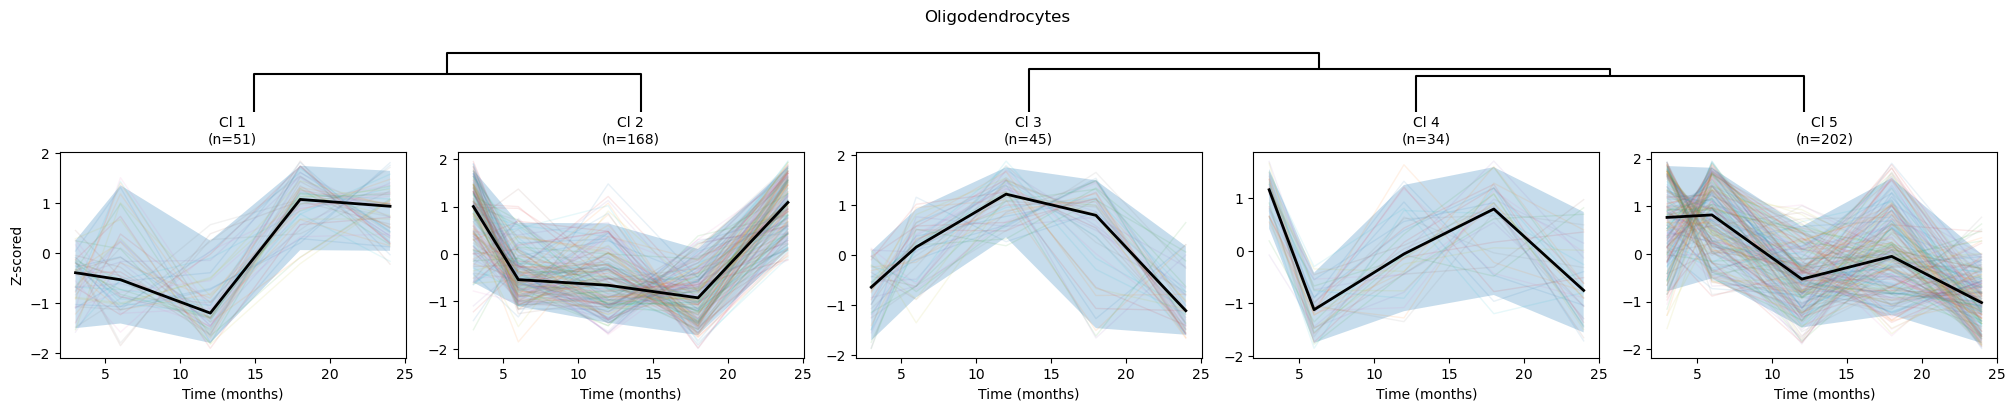

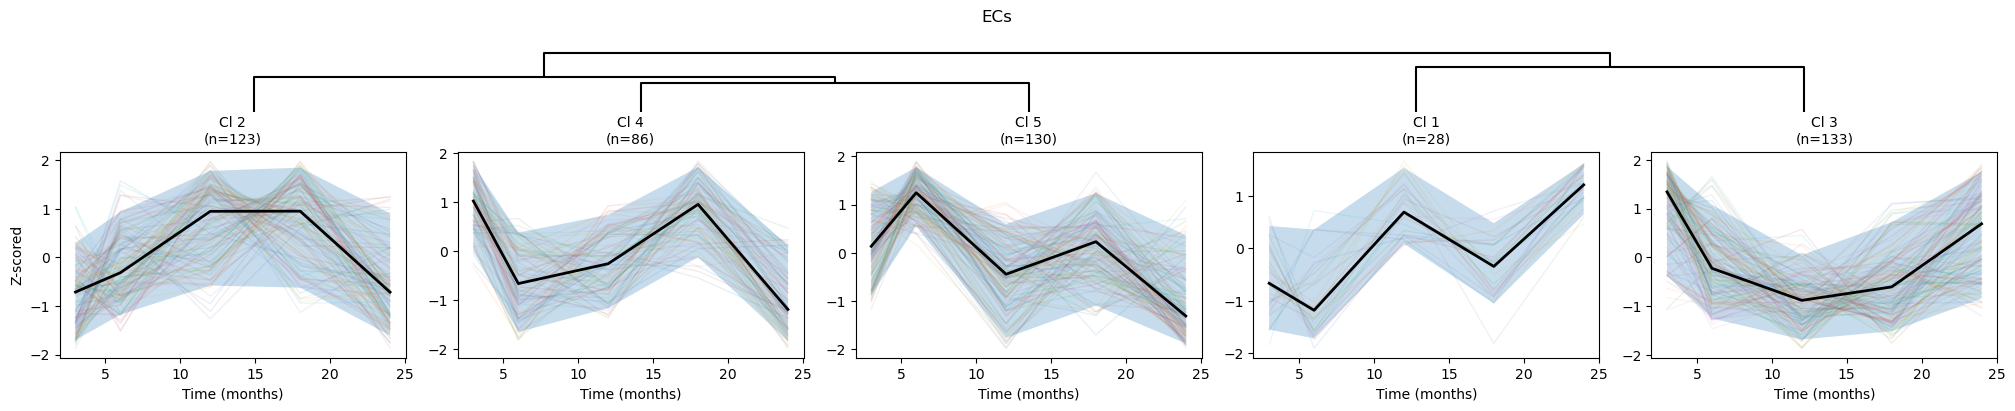

In [64]:
res_oligo = cluster_time_programs(adata_dict["Oligodendrocytes"])
res_ecs = cluster_time_programs(adata_dict["ECs"])

plot_ct_clusters(res_oligo, adata_dict["Oligodendrocytes"], "Oligodendrocytes")
plot_ct_clusters(res_ecs, adata_dict["ECs"], "ECs")